In [1]:
import sys
sys.path.append('../')
sys.path.append("../../")
import numpy as np
import matplotlib.pyplot as plt
import os
from pydicom import dcmread
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from types import MappingProxyType

from pydose_rt.data import MachineConfig
from models.layers import *
from models.utils.data import DataGenerator
from models.utils.plotting import *
from models.utils.kernel import *

/home/bolo/anaconda3/envs/autoplan/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:404: UserWarning: <built-in function array> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(
2025-09-02 21:22:55.487428: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-02 21:22:55.525964: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-02 21:22:56.145382: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
config = MachineConfig(ct_array_shape=(100, 100, 100), resolution=(0.5, 0.5, 0.5), field_size=(40, 40), number_of_leaf_pairs=1, tpr_20_10=0.72, number_of_cps=1)
print(config)

ct_array_shape=(100, 100, 100) resolution=(0.5, 0.5, 0.5) field_size=(40, 40) downsampling_factor=(1, 1, 1) iso_center=(0.0, 0.0, 0.0) minimum_leaf_overlap=0.5 maximum_leaf_speed=2.25 minimum_gantry_angle_speed=0.1 maximum_gantry_angle_speed=6.0 maximum_gantry_angle_speed_variation=0.75 minimum_dose_rate=50.0 maximum_dose_rate=600.0 is_fff=True mu_scaling=1.7958 focal_spot_sigma=0.15 focus_to_collimator=49.7 oar_coeffs=(1.0, -0.0001, 2.5e-07) mlc_thickness=6.8 mlc_mu=0.7 number_of_leaf_pairs=1 tpr_20_10=0.72 mean_photon_energy_MeV=6.0 SID=100.0 number_of_cps=1 starting_angle=0.0 mlc_transmission=0.00856560939749806 gantry_angles=array([0.]) depth_offset=100.0 gantry_diff=6.283185307179586 gantry_diff_deg=360.0 iso_center_in_pixels=array([0, 0, 0], dtype=int32) field_size_in_pixels=(80, 80) leaf_size=40.0 leaf_sizes=array([40.], dtype=float32) fluence_profile=(array([ 0.  ,  1.  ,  2.  ,  3.  ,  4.  ,  5.  ,  7.5 , 10.  , 12.5 ,
       15.  , 17.5 , 20.  , 25.  , 25.25, 25.75, 26.  , 50

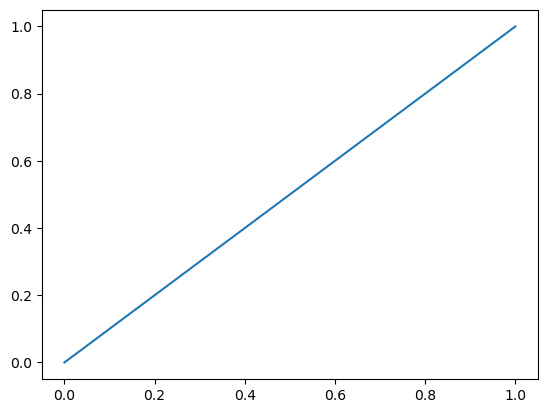

In [3]:
fluence_map_layer = FluenceMapLayer(config)  # Instantiate the FluenceMapLayer

num_points=1000
widths = np.linspace(0.0, 1.0, num_points)
open = []
for width in widths:
    y_mlc = np.zeros((1, 2, config.number_of_cps, config.number_of_leaf_pairs))
    y_mlc[:, 0, :, :] = 0.5
    y_mlc[:, 1, :, :] = width
    fluence_map = fluence_map_layer(torch.tensor(y_mlc, device=device)).cpu().detach().numpy()
    open.append(np.sum(fluence_map[0, :, 40, 0]) / 80)
plt.plot(widths, open)
plt.show()

For width 0.0 leaf is open: 0
For width 0.1 leaf is open: 720
For width 0.2 leaf is open: 1440
For width 0.3 leaf is open: 2000
For width 0.4 leaf is open: 2640
For width 0.5 leaf is open: 3200
For width 0.6 leaf is open: 3920
For width 0.7 leaf is open: 4560
For width 0.8 leaf is open: 5280
For width 1.0 leaf is open: 6400


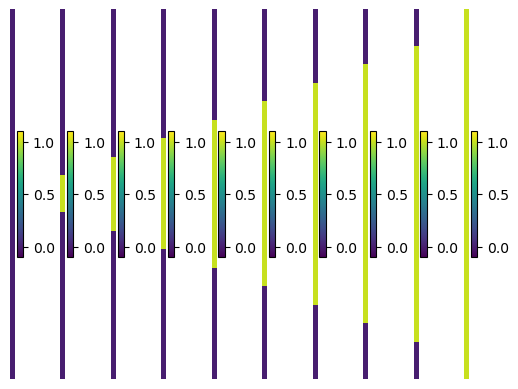

In [4]:
fluence_map_layer = FluenceMapLayer(config)  # Instantiate the FluenceMapLayer

widths = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
for width in widths:
    plt.subplot(1, len(widths), widths.index(width) + 1)
    y_mlc = np.zeros((1, 2, config.number_of_cps, config.number_of_leaf_pairs))
    y_mlc[:, 0, :, :] = 0.5
    y_mlc[:, 1, :, :] = width
    fluence_map = fluence_map_layer(torch.tensor(y_mlc, device=device)).cpu().detach().numpy()
    print(f"For width {width} leaf is open: {np.sum(fluence_map > 0.0)}")
    plt.imshow(fluence_map[0, :, fluence_map.shape[1]//2, :], vmin=-0.1, vmax=1.1)
    plt.axis('off')
    plt.colorbar()
plt.show()

In [ ]:
fluence_volume_layer = FluenceVolumeLayer(config)  # Instantiate the FluenceVolumeLayer with config
fluence_volume = fluence_volume_layer(torch.tensor(fluence_map, device=device)).cpu().detach().numpy()
print(fluence_volume.shape)
plt.imshow(fluence_volume[0, :, :, 50], interpolation='none')
plt.colorbar()
plt.show()
for i in range(0, fluence_volume.shape[1], 10):
    print(f"Depth: {i * config.resolution[0]}\twidth: {np.sum(fluence_volume[0, i, 50, :, 0] > 0) * config.resolution[2]}")

RuntimeError: expected scalar type Double but found Float

: 

In [ ]:
plt.plot(np.arange(0, fluence_volume.shape[1]), fluence_volume[0, :, 50, 50, 0])
plt.show()
print(np.sum((fluence_volume[0, :-1, 50, 50, 0] - fluence_volume[0, 1:, 50, 50, 0]) < 0))

In [ ]:
kernels = []

kernel_size = 65
pbm = PencilBeamModel(config, kernel_size)
rs = pbm.get_rs([kernel_size, kernel_size], config.resolution)
for depth in np.arange(0.0, 50.0, 0.3):
    kernels.append(pbm.get_nested_kernel(float(depth)))

kernels = np.stack(kernels, 0)
plt.imshow(kernels[:, :, kernel_size // 2])
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
# plt.subplot(121)
plt.plot(kernels[15, 25, :], label="Depth 15")
# plt.plot(kernels[120, 25, :], label="Depth 120")
# plt.imshow(np.log(kernels[15, :, :]), vmax=np.max(kernels))
# plt.subplot(122)

# plt.imshow(np.log(kernels[120, :, :]), vmax=np.max(kernels))

In [ ]:
x_ct = np.expand_dims(np.zeros(config.ct_array_shape), 0)
y_mlc = np.zeros((1, 2, config.number_of_cps, config.number_of_leaf_pairs))
y_mlc[:, 0, :, :] = 0.5
y_mlc[:, 1, :, :] = 1.0
mus = 0.1 * np.ones((1, config.number_of_cps), dtype=np.float32)
dose_layer = AccumulateDose3DLayer(config, 15)
dose = dose_layer(x_ct, y_mlc, mus)

In [ ]:
slice_idx = 84
print(dose.shape)

plt.imshow(dose[0, :, 84, :], cmap='jet', vmin=np.min(dose), vmax=np.max(dose))
plt.axis('off')
plt.colorbar()
# plt.axis('off')
plt.show()

In [ ]:
path ="/home/bolo/Downloads/10x10-10MV/RD1.2.752.243.1.1.20240927183310596.8800.73001.dcm"
path_ct = "/home/bolo/Downloads/10x10-10MV/CT1.2.752.243.1.1.20210112110104939.5560.87015.dcm"
ds = dcmread(path)
ds_ref = ds.pixel_array
ds_ref = np.transpose(ds_ref, (1, 2, 0))
print(ds_ref.shape)

plt.imshow(ds_ref[:, 84, :], cmap='jet')
plt.axis('off')
plt.colorbar()
plt.show()

In [ ]:
slice_idx = 84
print(dose.shape)
print(ds_ref.shape)

dose = dose * np.max(ds_ref[34, ...]) / np.max(dose[0, 34, ...])
# dose = dose * np.max(ds_ref) / np.max(dose)
plt.subplot(131)
plt.imshow(dose[0, :, 84, :], cmap='jet')
plt.axis('off')
plt.subplot(132)
plt.imshow(ds_ref[:, 84, :], cmap='jet')
plt.axis('off')
plt.subplot(133)
plt.imshow((ds_ref[:, 84, :] - dose[0, :, 84, :]) / (ds_ref[:, 84, :] + 1e-10), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.axis('off')
plt.show()

In [ ]:
air_gap = 1

print(config)

slice_idx = 84
depth_index = 92

x = np.linspace(0, config.ct_array_shape[0], config.ct_array_shape[0])

# Create the plot
plt.plot(x, dose[0, :, slice_idx, depth_index], label='TensorFlow', color='orange')
plt.plot(x, ds_ref[:, slice_idx, depth_index], label='Phantom', color='blue')
plt.legend()

# Set x-ticks from 0 to 128, but label them as 0 to 26
num_ticks = 10
new_xticks = np.linspace(0, config.ct_array_shape[0], num_ticks)  # 27 points from 0 to 128
new_xtick_labels = np.round(np.linspace(0, config.ct_array_shape[0]*config.resolution[0], num_ticks), 1)  # Corresponding labels from 0 to 26

# Apply the new ticks and labels
plt.xticks(new_xticks, new_xtick_labels)
plt.xlabel('[cm]')

# Show the plot
plt.show()

In [ ]:
print(config)

x = np.linspace(0, config.ct_array_shape[0], config.ct_array_shape[0])

# Create the plot
slices = np.linspace(5, config.ct_array_shape[0], 3, endpoint=False).astype(int)
line_styles = ['-', '--', ':']
for i in range(len(slices)):
  plt.plot(x, ds_ref[slices[i], :, slice_idx], label=f'Phantom (d={int(slices[i] * config.resolution[1])} cm)', color='blue', linestyle=line_styles[i])
  plt.plot(x, dose[0, slices[i], :, depth_index], label=f'Tensorflow (d={int(slices[i] * config.resolution[1])} cm)', color='orange', linestyle=line_styles[i])
plt.legend()

# Apply the new ticks and labels
plt.xticks(new_xticks, new_xtick_labels)
plt.xlabel('[cm]')

# Show the plot
plt.show()